# Building Neural Networks

## Goal

Build a neural network from scratch to understand how neural networks learn from data, update their parameters, and make predictions.

The project starts from the simplest possible model and evolves step by step toward multiclass classification, hidden layers, mini-batch training, and deeper networks.

---

## Version 5

Extend the network by adding a second hidden layer.

The model will:

- use all 10 Fashion-MNIST classes
- keep the 784 input pixels
- use a first hidden layer with 128 neurons and ReLU
- use a second hidden layer with 64 neurons and ReLU
- keep 10 output neurons with softmax
- use multiclass cross-entropy loss
- use mini-batch gradient descent
- shuffle the training data at the beginning of each epoch
- perform backpropagation through all three layers
- update all weights and biases after every mini-batch
- evaluate accuracy on the full Fashion-MNIST training and test sets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PATH = "/kaggle/input/datasets/zalando-research/fashionmnist/"

train = pd.read_csv(PATH + "fashion-mnist_train.csv")
test  = pd.read_csv(PATH + "fashion-mnist_test.csv")

In [3]:
train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

In [5]:
# Separate pixels from labels

X = train.drop(columns="label").values
y = train["label"].values

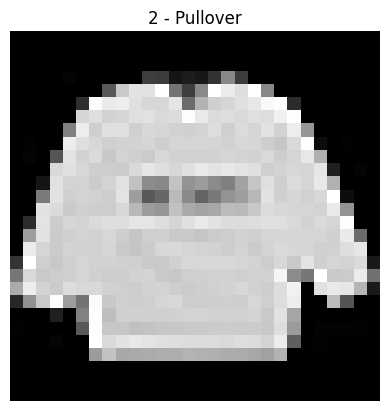

In [6]:
plt.imshow(X[0].reshape(28, 28), cmap="gray")
plt.title(f"{y[0]} - {labels[y[0]]}")
plt.axis("off")
plt.show()

In [7]:
# Normalize pixel values from 0-255 to 0-1

X = X / 255.0

y_onehot = np.eye(10)[y]

## Building the model

We now build a multiclass neural network with two hidden layers.

### Softmax activation

The softmax function converts the output scores into class probabilities that sum to `1`.

In [8]:
# Convert raw output scores into class probabilities

def softmax(z):
    exp = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

In [9]:
# Keep positive values and set negative values to zero

def relu(z):
    return np.maximum(0, z)

In [10]:
def train(X, y, w1, b1, w2, b2, w3, b3, lr=0.1, epochs=200, batch_size=64):
    for _ in range(epochs):
        batch_losses = []

        indices = np.random.permutation(len(X))

        X = X[indices]
        y = y[indices]
        
        for start in range(0, len(X), batch_size):

            end = start + batch_size

            X_batch = X[start:end]
            y_batch = y[start:end]
            
            z1 = X_batch @ w1 + b1
            a1 = relu(z1)
    
            z2 = a1 @ w2 + b2
            a2 = relu(z2)

            z3 = a2 @ w3 + b3
            pred = softmax(z3)
    
            # Prevent log(0) by keeping probabilities within a safe range
            loss = -np.mean(np.sum(y_batch * np.log(np.clip(pred, 1e-12, 1.0)), axis=1))
            
            batch_losses.append(loss)

            dz3 = pred - y_batch
            dw3 = a2.T @ dz3 / len(y_batch)
            db3 = np.mean(dz3, axis=0)
    
            da2 = dz3 @ w3.T
            dz2 = da2 * (z2 > 0)

            dw2 = a1.T @ dz2 / len(y_batch)
            db2 = np.mean(dz2, axis=0)
    
            da1 = dz2 @ w2.T
            dz1 = da1 * (z1 > 0)
    
            dw1 = X_batch.T @ dz1 / len(y_batch)
            db1 = np.mean(dz1, axis=0)

            w1 -= lr * dw1
            b1 -= lr * db1
            w2 -= lr * dw2
            b2 -= lr * db2
            w3 -= lr * dw3
            b3 -= lr * db3

        epoch_loss = np.mean(batch_losses)

    return w1, b1, w2, b2, w3, b3, epoch_loss

In [11]:
# Initialize three layers

np.random.seed(42)

w1 = np.random.randn(X.shape[1], 128) * np.sqrt(2 / X.shape[1])
b1 = np.zeros(128)

w2 = np.random.randn(128, 64) * np.sqrt(2 / 128)
b2 = np.zeros(64)

w3 = np.random.randn(64, 10) * np.sqrt(2 / 64)
b3 = np.zeros(10)

### Training

The model repeatedly measures its prediction error and updates all weights and biases to reduce the loss.

In [12]:
w1, b1, w2, b2, w3, b3, loss = train(X, y_onehot, w1, b1, w2, b2, w3, b3)

print(f"Train loss: {loss:.4f}")

Train loss: 0.0145


## Evaluation

The model predicts the class with the highest probability.

In [13]:
z1 = X @ w1 + b1
a1 = relu(z1)

z2 = a1 @ w2 + b2
a2 = relu(z2)

z3 = a2 @ w3 + b3
pred = softmax(z3)

y_pred = np.argmax(pred, axis=1)
accuracy = np.mean(y_pred == y)

print(f"Train accuracy: {accuracy:.2%}")

Train accuracy: 99.59%


In [14]:
X_test = test.drop(columns="label").values / 255.0
y_test = test["label"].values

z1 = X_test @ w1 + b1
a1 = relu(z1)

z2 = a1 @ w2 + b2
a2 = relu(z2)

z3 = a2 @ w3 + b3
pred = softmax(z3)

preds = np.argmax(pred, axis=1)

accuracy = np.mean(preds == y_test)

print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 89.92%


## Notes

This fifth version extends the network by adding a second hidden layer.

- All 10 Fashion-MNIST classes are used.
- Images are flattened into 784 pixel values and normalized to `0-1`.
- The first hidden layer uses 128 neurons with ReLU.
- The second hidden layer uses 64 neurons with ReLU.
- The output layer uses 10 neurons, one for each class.
- Softmax converts the output scores into class probabilities.
- Multiclass cross-entropy measures the error.
- The training data is shuffled at the beginning of each epoch.
- The dataset is divided into small mini-batches.
- Forward propagation passes through both hidden layers.
- Backpropagation computes gradients through all three layers.
- Weights and biases are updated after every mini-batch.
- Final predictions use the class with the highest probability.
- The model is evaluated on the full Fashion-MNIST training and test sets.
- Random initialization uses a fixed seed for reproducible results.
- Training runs for a fixed number of epochs.

This version completes the five-stage Building Neural Networks project.